In [59]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [60]:
df = pd.read_csv('https://github.com/lowoncuties/VSB-FEI-Machine-Learning-Exercises/raw/main/datasets/ml_06/iris.csv')
print(df.head())


   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


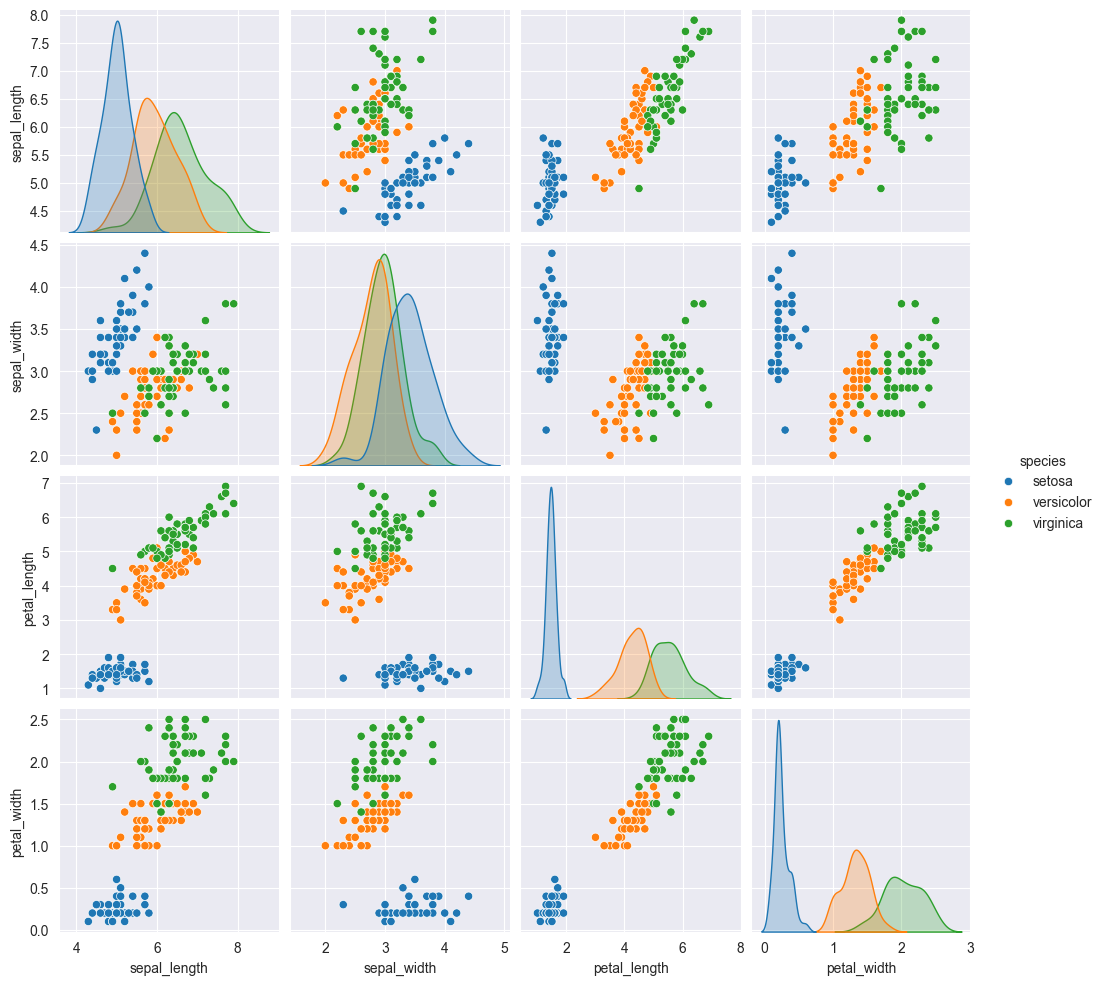

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue="species")
plt.show()


In [62]:
def mean(values):
    return sum(values) / len(values)

In [63]:
def variance(values,mean):
    return sum([(x-mean)**2 for x in values])/ len(values)

In [64]:

def gaussian_probability(x, mean, var): 
    exponent = math.exp(-((x - mean) ** 2) / (2 * var)) 
    return (1 / math.sqrt(2 * math.pi * var)) * exponent


'\ndef gaussian_probability(x, mean, variance):\n    exponent = (-((x - mean) ** 2)) / (2 * variance)\n    return (1 / (2* 3.14159 * variance) ** 0.5) * (2.71828 ** exponent)\n'

In [65]:
from sklearn.model_selection import train_test_split

X = df.drop('species', axis=1)
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
class NaiveBayes:
    def fit(self,X,y):
        self.classes = set(y) #jedinecne hodntoy
        self.summaries = {}
        for c in self.classes:
            X_c = [X[i] for i in range(len(X)) if y[i] == c]
            features = list(zip(*X_c))
            summaries = []
            for feature in features:
                mean_val = mean(feature)
                var_val = variance(feature, mean_val)
                summaries.append((mean_val, var_val))
            self.summaries[c] = summaries
    def predict(self,X):
        return [self._predict_single(sample) for sample in X]
    
    def _predict_single(self, sample):
        posterior_probs = {}
        for c in self.classes:
            prior = math.log(sum(1 for label in y_train if label == c) / len(y_train))  # P(c)
            likelihood = 0
            for i in range(len(sample)):
                mean_val, var_val = self.summaries[c][i]
                likelihood += math.log(gaussian_probability(sample[i], mean_val, var_val))  # P(x_i | c)
            posterior_probs[c] = prior + likelihood
        
        return max(self.classes, key=lambda c: posterior_probs[c])
            

In [67]:
model = NaiveBayes()
model.fit(X_train.values, y_train.values)
predictions = model.predict(X_test.values)

accuracy = sum(1 for i in range(len(y_test)) if y_test.values[i] == predictions[i]) / len(y_test)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 100.00%


Scikit-learn Accuracy: 100.00%


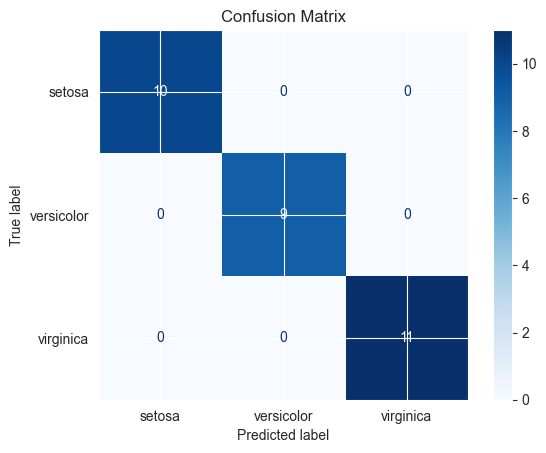

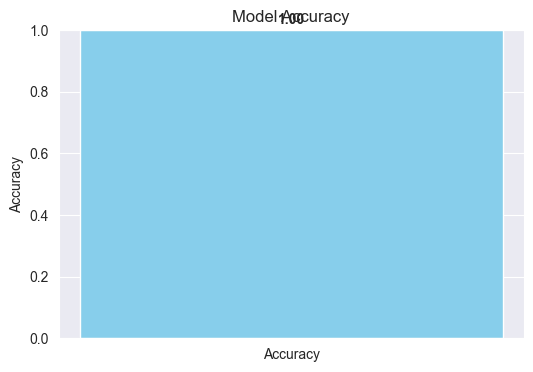

In [68]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB

sklearn_model = GaussianNB()
sklearn_model.fit(X_train, y_train)
sklearn_predictions = sklearn_model.predict(X_test)

sklearn_accuracy = sum(1 for i in range(len(y_test)) if y_test.values[i] == sklearn_predictions[i]) / len(y_test)
print(f'Scikit-learn Accuracy: {sklearn_accuracy * 100:.2f}%')

# Vizualizácia konfúznej matice
cm = confusion_matrix(y_test, sklearn_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sklearn_model.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Vizualizácia presnosti ako barového grafu
metrics = ['Accuracy']
values = [sklearn_accuracy]

plt.figure(figsize=(6, 4))
plt.bar(metrics, values, color='skyblue')
plt.ylim(0, 1)
plt.title('Model Accuracy')
plt.ylabel('Accuracy')

# Zobrazenie hodnoty presnosti na grafe
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()

NaiveBayes Accuracy: 100.00%
NaiveBayes Fit Time: 0.0009 seconds
NaiveBayes Predict Time: 0.0051 seconds
NaiveBayes Total Time: 0.0061 seconds
Scikit-learn Accuracy: 100.00%
Scikit-learn Fit Time: 0.0046 seconds
Scikit-learn Predict Time: 0.0028 seconds
Scikit-learn Total Time: 0.0074 seconds


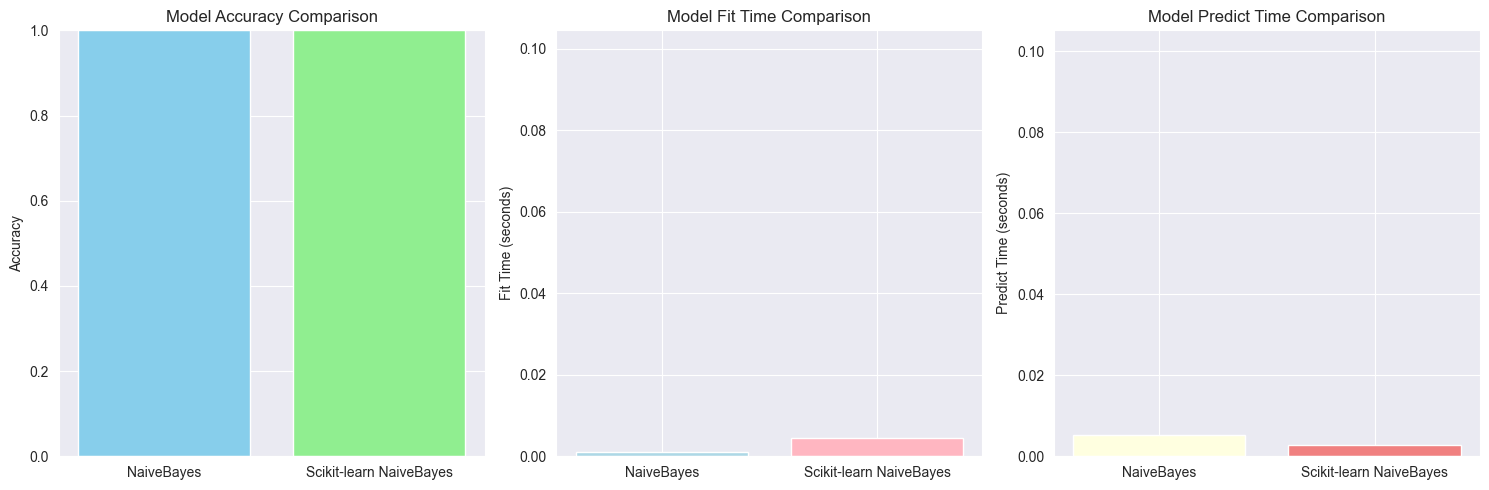

In [69]:
import time
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB

# Časová evaluácia pre NaiveBayes model (vlastný)
start_fit_naivebayes = time.time()
model = NaiveBayes()
model.fit(X_train.values, y_train.values)
fit_naivebayes_time = time.time() - start_fit_naivebayes

start_predict_naivebayes = time.time()
predictions_naivebayes = model.predict(X_test.values)
predict_naivebayes_time = time.time() - start_predict_naivebayes

naivebayes_time = fit_naivebayes_time + predict_naivebayes_time  # Celkový čas pre NaiveBayes

# Vypočítať presnosť pre vlastný model
accuracy_naivebayes = accuracy_score(y_test, predictions_naivebayes)
print(f'NaiveBayes Accuracy: {accuracy_naivebayes * 100:.2f}%')
print(f'NaiveBayes Fit Time: {fit_naivebayes_time:.4f} seconds')
print(f'NaiveBayes Predict Time: {predict_naivebayes_time:.4f} seconds')
print(f'NaiveBayes Total Time: {naivebayes_time:.4f} seconds')

# Časová evaluácia pre sklearn's GaussianNB
start_fit_sklearn = time.time()
sklearn_model = GaussianNB()
sklearn_model.fit(X_train, y_train)
fit_sklearn_time = time.time() - start_fit_sklearn

start_predict_sklearn = time.time()
sklearn_predictions = sklearn_model.predict(X_test)
predict_sklearn_time = time.time() - start_predict_sklearn

sklearn_time = fit_sklearn_time + predict_sklearn_time  # Celkový čas pre sklearn

# Vypočítať presnosť pre knižnicový model
accuracy_sklearn = accuracy_score(y_test, sklearn_predictions)
print(f'Scikit-learn Accuracy: {accuracy_sklearn * 100:.2f}%')
print(f'Scikit-learn Fit Time: {fit_sklearn_time:.4f} seconds')
print(f'Scikit-learn Predict Time: {predict_sklearn_time:.4f} seconds')
print(f'Scikit-learn Total Time: {sklearn_time:.4f} seconds')

# Zobrazenie porovnania času a presnosti
models = ['NaiveBayes', 'Scikit-learn NaiveBayes']
accuracies = [accuracy_naivebayes, accuracy_sklearn]
times = [naivebayes_time, sklearn_time]

# Časy pre fit a predict
fit_times = [fit_naivebayes_time, fit_sklearn_time]
predict_times = [predict_naivebayes_time, predict_sklearn_time]

# Graf presnosti
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.bar(models, accuracies, color=['skyblue', 'lightgreen'])
plt.ylim(0, 1)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')

# Graf času pre fit
plt.subplot(1, 3, 2)
plt.bar(models, fit_times, color=['lightblue', 'lightpink'])
plt.ylim(0, max(fit_times) + 0.1)
plt.title('Model Fit Time Comparison')
plt.ylabel('Fit Time (seconds)')

# Graf času pre predict
plt.subplot(1, 3, 3)
plt.bar(models, predict_times, color=['lightyellow', 'lightcoral'])
plt.ylim(0, max(predict_times) + 0.1)
plt.title('Model Predict Time Comparison')
plt.ylabel('Predict Time (seconds)')

# Zobrazenie grafov
plt.tight_layout()
plt.show()
